# 01 — Veri Hazırlama ve Kalite Kontrolü

## Proje bağlamı

**The Complete Journey**, 2.500 hanenin yaklaşık iki yıllık perakende işlemlerini;
ürün, demografi, kampanya ve kupon tablolarıyla birlikte sunan ilişkisel bir veri
setidir.

Projenin ana amacı, hanelerin geçmiş alışveriş davranışlarından yararlanarak gelecek
dönemde **pasifleşme riskini tahmin etmek**, müşterileri davranışlarına göre
**segmentlere ayırmak** ve sonuçları açıklanabilir bir karar destek uygulamasında
sunmaktır.

Bu notebook yalnızca ortak veri hazırlama katmanını kurar. Ayrıntılı EDA, özellik
mühendisliği ve modelleme sonraki notebook'larda yapılacaktır.

### Bu notebook'un çıktıları

- Bütün tablolar için standart sütun isimleri
- Veri envanteri ve kalite özeti
- Anahtar, benzersizlik ve ilişkisel kapsam kontrolleri
- Kupon tablosundaki tam tekrarların temizlenmesi
- Ürün tablosundaki gizli boş değerlerin gerçek eksik değere dönüştürülmesi
- Sonraki notebook'ların okuyacağı temiz Parquet dosyaları

> `causal_data` yaklaşık 36,8 milyon satır olduğu ve ilk model için zorunlu olmadığı
> için başlangıç sürümüne dahil edilmemiştir. Zaman kalırsa mağaza içi gösterim ve
> broşür etkisini incelemek amacıyla bonus analiz olarak eklenebilir.


> Ham veriler `data/raw` klasöründe değişmeden korunacaktır. Temizlenmiş temel
> tablolar `data/interim`, modellemeye hazır özellik tabloları ise
> `data/processed` klasöründe saklanacaktır.

## 1. Kütüphaneler ve proje yolları

Kod, notebook'un proje kökünden veya `notebooks/` klasöründen açılması durumlarını
desteklemek için olası veri klasörlerini sırayla kontrol eder. Ekipte herkesin aynı
klasör yapısını kullanması önerilir:

```text
project/
├── data/
│   ├── raw/
│   ├── interim/
│   └── processed/
└── notebooks/
```


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 240)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")


def first_existing_path(candidates):
    """İlk bulunan klasörü döndürür; bulunamazsa açıklayıcı hata verir."""
    for candidate in candidates:
        candidate = Path(candidate)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Veri klasörü bulunamadı. Beklenen seçenekler: "
        + ", ".join(map(str, candidates))
    )


RAW_PATH = first_existing_path([
    "data/raw",
    "../data/raw",
    "data_raw",
    "../data_raw",
])

if RAW_PATH.name == "raw":
    DATA_ROOT = RAW_PATH.parent
else:
    DATA_ROOT = RAW_PATH.parent / "data"

PROCESSED_PATH = DATA_ROOT / "processed"
INTERIM_PATH = DATA_ROOT / "interim"

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)
INTERIM_PATH.mkdir(parents=True, exist_ok=True)

print(f"Ham veri klasörü : {RAW_PATH.resolve()}")
print(f"İşlenmiş veri    : {PROCESSED_PATH.resolve()}")
print(f"Ara çıktılar     : {INTERIM_PATH.resolve()}")


import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

sns.set_theme(style="whitegrid", palette="deep")


Ham veri klasörü : C:\Users\ed024981\Desktop\Miuul_project\data\raw
İşlenmiş veri    : C:\Users\ed024981\Desktop\Miuul_project\data\processed
Ara çıktılar     : C:\Users\ed024981\Desktop\Miuul_project\data\interim


## 2. Beklenen dosyaların doğrulanması

Analize başlamadan önce gerekli CSV dosyalarının tamamının bulunup bulunmadığı
kontrol edilir. Eksik bir dosya varsa süreç erken durdurulur; böylece ilerleyen
hücrelerde anlaşılması zor hatalar oluşmaz.


In [2]:
TABLE_FILES = {
    "campaign_desc": "campaign_desc.csv",
    "campaign_table": "campaign_table.csv",
    "coupon_redempt": "coupon_redempt.csv",
    "coupon": "coupon.csv",
    "hh_demographic": "hh_demographic.csv",
    "product": "product.csv",
    "transaction_data": "transaction_data.csv",
}

missing_files = [
    filename
    for filename in TABLE_FILES.values()
    if not (RAW_PATH / filename).exists()
]

if missing_files:
    raise FileNotFoundError(f"Eksik ham veri dosyaları: {missing_files}")

print("Gerekli ham veri dosyalarının tamamı bulundu.")


Gerekli ham veri dosyalarının tamamı bulundu.


## 3. Ham veri tabloların yüklenmesi

Ham dosyalar değiştirilmeden okunur. Ardından her tablo üzerinde ayrı bir kopya
oluşturulacağı için ham CSV dosyaları veri kaynağı olarak korunur.


In [3]:
tables = {
    table_name: pd.read_csv(RAW_PATH / filename, low_memory=False)
    for table_name, filename in TABLE_FILES.items()
}

for table_name, dataframe in tables.items():
    print(f"{table_name:20} -> {dataframe.shape}")


campaign_desc        -> (30, 4)
campaign_table       -> (7208, 3)
coupon_redempt       -> (2318, 4)
coupon               -> (124548, 3)
hh_demographic       -> (801, 8)
product              -> (92353, 7)
transaction_data     -> (2595732, 12)


## 4. Sütun isimlerinin standartlaştırılması

Bütün sütun isimleri küçük harfe çevrilir, baştaki/sondaki boşluklar kaldırılır ve
boşluklar alt çizgiyle değiştirilir. Bu işlem tablo birleşimlerinde yazım kaynaklı
hataları azaltır.


In [4]:
def standardize_columns(dataframe):
    dataframe = dataframe.copy()
    dataframe.columns = (
        dataframe.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", "_", regex=True)
    )
    return dataframe


tables = {
    table_name: standardize_columns(dataframe)
    for table_name, dataframe in tables.items()
}

campaign_desc = tables["campaign_desc"]
campaign_table = tables["campaign_table"]
coupon_redempt = tables["coupon_redempt"]
coupon = tables["coupon"]
hh_demographic = tables["hh_demographic"]
product = tables["product"]
transaction_data = tables["transaction_data"]

for table_name, dataframe in tables.items():
    print(f"{table_name:20}: {dataframe.columns.tolist()}")


campaign_desc       : ['description', 'campaign', 'start_day', 'end_day']
campaign_table      : ['description', 'household_key', 'campaign']
coupon_redempt      : ['household_key', 'day', 'coupon_upc', 'campaign']
coupon              : ['coupon_upc', 'product_id', 'campaign']
hh_demographic      : ['classification_1', 'classification_2', 'classification_3', 'homeowner_desc', 'classification_5', 'classification_4', 'kid_category_desc', 'household_key']
product             : ['product_id', 'manufacturer', 'department', 'brand', 'commodity_desc', 'sub_commodity_desc', 'curr_size_of_product']
transaction_data    : ['household_key', 'basket_id', 'day', 'product_id', 'quantity', 'sales_value', 'store_id', 'retail_disc', 'trans_time', 'week_no', 'coupon_disc', 'coupon_match_disc']


## 5. Ortak veri kontrol fonksiyonu

Standart `isna()` kontrolüne ek olarak boş string değerleri de taranır. Çünkü CSV
dosyalarında bazı eksik değerler `NaN` yerine `""` veya yalnızca boşluk olarak
saklanabilir.


In [5]:
def hidden_blank_count(dataframe):
    string_cols = dataframe.select_dtypes(include=["object", "string"]).columns
    if len(string_cols) == 0:
        return pd.Series(dtype="int64")
    counts = dataframe[string_cols].apply(
        lambda series: series.fillna("").astype(str).str.strip().eq("").sum()
    )
    return counts[counts > 0].sort_values(ascending=False)


def check_df(dataframe, head=5):
    print("#" * 20, "SHAPE", "#" * 20)
    print(dataframe.shape)
    print("\n", "#" * 20, "DTYPES", "#" * 20)
    print(dataframe.dtypes)
    print("\n", "#" * 20, "HEAD", "#" * 20)
    display(dataframe.head(head))
    print("\n", "#" * 20, "MISSING", "#" * 20)
    missing = dataframe.isna().sum()
    display(missing[missing > 0].sort_values(ascending=False).to_frame("missing"))
    print("\n", "#" * 20, "HIDDEN BLANKS", "#" * 20)
    display(hidden_blank_count(dataframe).to_frame("blank_string"))
    print("\n", "#" * 20, "DUPLICATES", "#" * 20)
    print(f"Tam tekrar eden satır: {dataframe.duplicated().sum():,}")
    memory_mb = dataframe.memory_usage(deep=True).sum() / 1024**2
    print(f"Bellek kullanımı: {memory_mb:,.2f} MB")


## 6. Veri envanteri

Bu özet, kullanılan veri sürümünü dokümante eder ve kalite sorunlarının hangi
tablolarda yoğunlaştığını tek yerde gösterir.


In [6]:
def create_data_inventory(table_dict):
    records = []
    for table_name, dataframe in table_dict.items():
        records.append({
            "table": table_name,
            "rows": len(dataframe),
            "columns": dataframe.shape[1],
            "missing_cells": int(dataframe.isna().sum().sum()),
            "hidden_blank_cells": int(hidden_blank_count(dataframe).sum()),
            "duplicated_rows": int(dataframe.duplicated().sum()),
            "memory_mb": dataframe.memory_usage(deep=True).sum() / 1024**2,
        })
    return (
        pd.DataFrame(records)
        .sort_values("rows", ascending=False)
        .reset_index(drop=True)
    )


data_inventory = create_data_inventory(tables)
data_inventory


,table,rows,columns,missing_cells,hidden_blank_cells,duplicated_rows,memory_mb
0,transaction_data,2595732,12,0,0,0,237.646
1,coupon,124548,3,0,0,5164,2.851
2,product,92353,7,0,30652,0,9.543
3,campaign_table,7208,3,0,0,0,0.199
4,coupon_redempt,2318,4,0,0,0,0.071
5,hh_demographic,801,8,0,0,0,0.081
6,campaign_desc,30,4,0,0,0,0.001


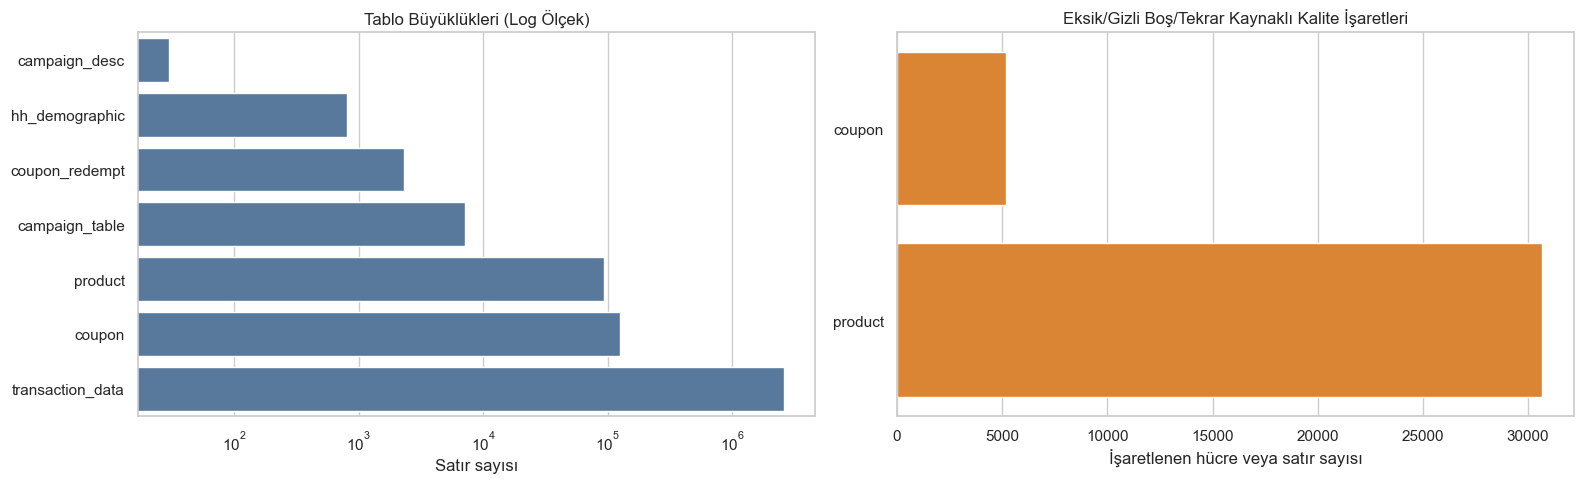

In [7]:
inventory_plot = data_inventory.copy()
inventory_plot["quality_issue_cells"] = (
    inventory_plot["missing_cells"]
    + inventory_plot["hidden_blank_cells"]
    + inventory_plot["duplicated_rows"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=inventory_plot.sort_values("rows"),
    x="rows", y="table", color="#4C78A8", ax=axes[0]
)
axes[0].set_xscale("log")
axes[0].set_title("Tablo Büyüklükleri (Log Ölçek)")
axes[0].set_xlabel("Satır sayısı")
axes[0].set_ylabel("")

quality_plot = inventory_plot.loc[
    inventory_plot["quality_issue_cells"].gt(0)
].sort_values("quality_issue_cells")
sns.barplot(
    data=quality_plot,
    x="quality_issue_cells", y="table", color="#F58518", ax=axes[1]
)
axes[1].set_title("Eksik/Gizli Boş/Tekrar Kaynaklı Kalite İşaretleri")
axes[1].set_xlabel("İşaretlenen hücre veya satır sayısı")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


### Envanter nasıl yorumlanmalı?

- `missing_cells`, standart eksik değerleri gösterir.
- `hidden_blank_cells`, özellikle ürün metin alanlarındaki görünmeyen boşlukları
  yakalar.
- `duplicated_rows`, bütün sütunları aynı olan tam tekrarları sayar.
- Bir tabloda eksik hücre bulunmaması, o tablonun bütün haneleri veya ürünleri
  kapsadığı anlamına gelmez. Kapsama ayrıca kontrol edilmelidir.


## 7. Aday anahtar ve benzersizlik kontrolleri

İlişkisel tablolarda birleşme yapmadan önce anahtarların benzersizliği doğrulanır.
Aksi ha
lde beklenmeyen `many-to-many` birleşmeler satır sayısını ve toplamları
yapay olarak artırabilir.


In [8]:
def uniqueness_record(table_name, key_name, dataframe, key_columns):
    unique_count = dataframe[key_columns].drop_duplicates().shape[0]
    return {
        "table": table_name,
        "candidate_key": " + ".join(key_columns),
        "row_count": len(dataframe),
        "unique_key_count": unique_count,
        "is_unique": unique_count == len(dataframe),
    }


key_checks = pd.DataFrame([
    uniqueness_record("transaction_data", "transaction row", transaction_data, list(transaction_data.columns)),
    uniqueness_record("product", "product_id", product, ["product_id"]),
    uniqueness_record("hh_demographic", "household_key", hh_demographic, ["household_key"]),
    uniqueness_record("campaign_desc", "campaign", campaign_desc, ["campaign"]),
    uniqueness_record("coupon", "coupon-product-campaign", coupon, ["coupon_upc", "product_id", "campaign"]),
])

key_checks


,table,candidate_key,row_count,unique_key_count,is_unique
0,transaction_data,household_key + basket_id + day + product_id +...,2595732,2595732,True
1,product,product_id,92353,92353,True
2,hh_demographic,household_key,801,801,True
3,campaign_desc,campaign,30,30,True
4,coupon,coupon_upc + product_id + campaign,124548,119384,False


## 8. Kupon tekrarlarının incelenmesi ve temizlenmesi

Bir kuponun birden fazla üründe geçerli olması normaldir. Bu nedenle yalnızca
`coupon_upc` tekrarına bakılarak kayıt silinmez. Ancak `coupon_upc`, `product_id`
ve `campaign` değerlerinin tamamı aynıysa kayıt gerçek bir tam tekrardır.


In [9]:
coupon_duplicate_groups = (
    coupon.groupby(["coupon_upc", "product_id", "campaign"])
    .size()
    .reset_index(name="record_count")
    .query("record_count > 1")
    .sort_values("record_count", ascending=False)
)

print(f"Tekrarlı kupon grubu: {len(coupon_duplicate_groups):,}")
display(coupon_duplicate_groups.head(20))

coupon_clean = coupon.drop_duplicates().reset_index(drop=True)

print(f"Temizleme öncesi : {len(coupon):,}")
print(f"Temizleme sonrası: {len(coupon_clean):,}")
print(f"Kaldırılan tekrar: {len(coupon) - len(coupon_clean):,}")


Tekrarlı kupon grubu: 1,824


,coupon_upc,product_id,campaign,record_count
118590,57940011075,921912,27,19
118724,57940011080,921912,27,19
118877,57940018076,6704447,27,17
118911,57940018081,6704447,27,17
118912,57940018081,7167488,27,16
118878,57940018076,7167488,27,16
109767,54589314175,1024433,27,16
109932,54589314187,1024433,27,16
118965,57940041075,933409,27,15
106475,54100027032,1118641,27,15


Temizleme öncesi : 124,548
Temizleme sonrası: 119,384
Kaldırılan tekrar: 5,164


## 9. Ürün tablosundaki gizli boş değerlerin standartlaştırılması

Ürün tablosundaki boş string değerleri `NaN` haline getirilir. Bu işlem bir satırı
silmez, yalnızca eksik bilginin doğru biçimde temsil edilmesini sağlar.


In [10]:
product_clean = product.copy()
product_string_cols = product_clean.select_dtypes(include=["object", "string"]).columns

product_clean[product_string_cols] = product_clean[product_string_cols].apply(
    lambda series: series.replace(r"^\s*$", np.nan, regex=True)
)

product_missing_after = (
    product_clean.isna().sum()
    .loc[lambda series: series > 0]
    .sort_values(ascending=False)
    .to_frame("missing_after_standardization")
)
product_missing_after


,missing_after_standardization
curr_size_of_product,30607
department,15
commodity_desc,15
sub_commodity_desc,15


## 10. Tablolar arası kapsam ve yetim kayıt kontrolleri

Bu bölüm, birleşmelerde karşılığı bulunmayan ürün, kampanya veya hane kayıtlarını
sayar. Sonucun sıfır olması ilgili ilişkinin tam kapsandığını gösterir.


In [11]:
relation_checks = pd.DataFrame([
    {
        "relation": "transaction_data.product_id -> product.product_id",
        "left_unique": transaction_data["product_id"].nunique(),
        "unmatched_unique": transaction_data.loc[
            ~transaction_data["product_id"].isin(product_clean["product_id"]),
            "product_id",
        ].nunique(),
    },
    {
        "relation": "campaign_table.campaign -> campaign_desc.campaign",
        "left_unique": campaign_table["campaign"].nunique(),
        "unmatched_unique": campaign_table.loc[
            ~campaign_table["campaign"].isin(campaign_desc["campaign"]),
            "campaign",
        ].nunique(),
    },
    {
        "relation": "coupon.campaign -> campaign_desc.campaign",
        "left_unique": coupon_clean["campaign"].nunique(),
        "unmatched_unique": coupon_clean.loc[
            ~coupon_clean["campaign"].isin(campaign_desc["campaign"]),
            "campaign",
        ].nunique(),
    },
    {
        "relation": "coupon.product_id -> product.product_id",
        "left_unique": coupon_clean["product_id"].nunique(),
        "unmatched_unique": coupon_clean.loc[
            ~coupon_clean["product_id"].isin(product_clean["product_id"]),
            "product_id",
        ].nunique(),
    },
    {
        "relation": "coupon_redempt.campaign -> campaign_desc.campaign",
        "left_unique": coupon_redempt["campaign"].nunique(),
        "unmatched_unique": coupon_redempt.loc[
            ~coupon_redempt["campaign"].isin(campaign_desc["campaign"]),
            "campaign",
        ].nunique(),
    },
])

relation_checks


,relation,left_unique,unmatched_unique
0,transaction_data.product_id -> product.product_id,92339,0
1,campaign_table.campaign -> campaign_desc.campaign,30,0
2,coupon.campaign -> campaign_desc.campaign,30,0
3,coupon.product_id -> product.product_id,44133,0
4,coupon_redempt.campaign -> campaign_desc.campaign,30,0


### Demografik kapsama

Demografi tablosu yalnızca hanelerin bir bölümünü kapsar. Bu nedenle demografiyi
işlem tablosuna `inner join` ile bağlamak, çok sayıda haneyi analizden düşürür.
Modelleme aşamasında ana evren işlem tablosundaki haneler olmalı; demografi varsa
`left join` ile eklenmelidir.


In [12]:
transaction_households = set(transaction_data["household_key"].unique())
demographic_households = set(hh_demographic["household_key"].unique())

demographic_coverage = pd.Series({
    "transaction_households": len(transaction_households),
    "households_with_demographics": len(transaction_households & demographic_households),
    "household_level_coverage": len(transaction_households & demographic_households) / len(transaction_households),
    "transaction_level_coverage": transaction_data["household_key"].isin(demographic_households).mean(),
})

demographic_coverage


transaction_households         2,500.000
households_with_demographics     801.000
household_level_coverage           0.320
transaction_level_coverage         0.550
dtype: float64

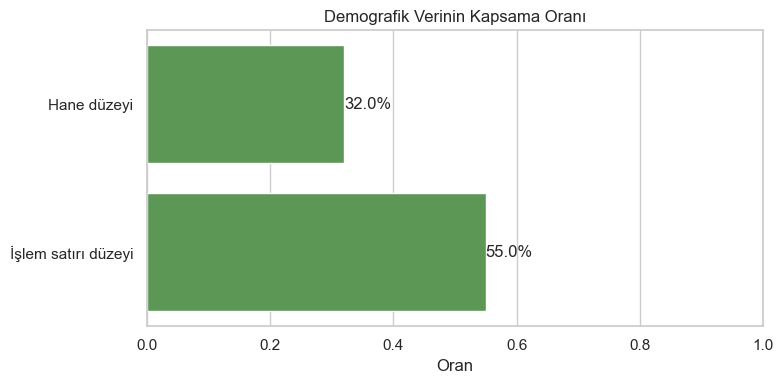

In [13]:
coverage_plot = pd.DataFrame({
    "Kapsama": ["Hane düzeyi", "İşlem satırı düzeyi"],
    "Oran": [
        demographic_coverage["household_level_coverage"],
        demographic_coverage["transaction_level_coverage"],
    ],
})

plt.figure(figsize=(8, 4))
ax = sns.barplot(data=coverage_plot, x="Oran", y="Kapsama", color="#54A24B")
ax.set_xlim(0, 1)
ax.set_title("Demografik Verinin Kapsama Oranı")
ax.set_xlabel("Oran")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], labels=[f"{v:.1%}" for v in coverage_plot["Oran"]])
plt.tight_layout()
plt.show()


## 11. Temel iş kuralları ve şüpheli işlem bayrakları

Şüpheli değerler otomatik olarak silinmez. Yüksek `quantity` değerleri
özel ürünlerden, sıfır satışlar ise ücretsiz/promosyonel işlemlerden kaynaklanabilir.
Bu hücre yalnızca araştırılması gereken durumları sayar.


In [14]:
campaign_bounds_check = pd.Series({
    "start_after_end": int((campaign_desc["start_day"] > campaign_desc["end_day"]).sum()),
    "campaigns_outside_transaction_days": int((
        (campaign_desc["start_day"] < transaction_data["day"].min())
        | (campaign_desc["end_day"] > transaction_data["day"].max())
    ).sum()),
})

transaction_quality_flags = pd.Series({
    "zero_quantity": int(transaction_data["quantity"].eq(0).sum()),
    "negative_quantity": int(transaction_data["quantity"].lt(0).sum()),
    "zero_sales": int(transaction_data["sales_value"].eq(0).sum()),
    "negative_sales": int(transaction_data["sales_value"].lt(0).sum()),
    "positive_retail_discount": int(transaction_data["retail_disc"].gt(0).sum()),
    "positive_coupon_discount": int(transaction_data["coupon_disc"].gt(0).sum()),
    "positive_coupon_match_discount": int(transaction_data["coupon_match_disc"].gt(0).sum()),
    "quantity_above_100": int(transaction_data["quantity"].gt(100).sum()),
})

print("Kampanya tarih kontrolleri")
display(campaign_bounds_check.to_frame("count"))
print("İşlem kalite bayrakları")
display(transaction_quality_flags.to_frame("count"))


Kampanya tarih kontrolleri


,count
start_after_end,0
campaigns_outside_transaction_days,1


İşlem kalite bayrakları


,count
zero_quantity,14466
negative_quantity,0
zero_sales,18850
negative_sales,0
positive_retail_discount,36
positive_coupon_discount,0
positive_coupon_match_discount,0
quantity_above_100,23136


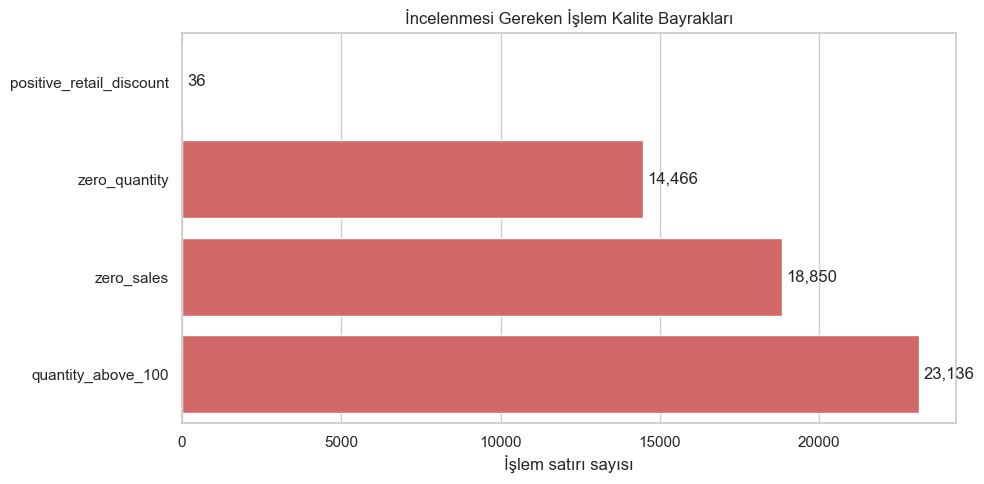

In [15]:
flag_plot = (
    transaction_quality_flags[transaction_quality_flags.gt(0)]
    .sort_values()
    .rename_axis("quality_flag")
    .reset_index(name="count")
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=flag_plot, x="count", y="quality_flag", color="#E45756")
ax.set_title("İncelenmesi Gereken İşlem Kalite Bayrakları")
ax.set_xlabel("İşlem satırı sayısı")
ax.set_ylabel("")
ax.bar_label(
    ax.containers[0],
    labels=[f"{value:,.0f}" for value in flag_plot["count"]],
    padding=3,
)
plt.tight_layout()
plt.show()


## 12. Kupon kullanımlarının kampanya tarihleriyle doğrulanması

Kullanım günü, kampanyanın başlangıç ve bitiş günü arasında olmalıdır. Tarih dışı
kullanımlar varsa silmeden önce User Guide ve iş kuralı açısından incelenmelidir.


In [16]:
redemption_with_dates = coupon_redempt.merge(
    campaign_desc[["campaign", "description", "start_day", "end_day"]],
    on="campaign",
    how="left",
    validate="many_to_one",
)

redemption_with_dates["within_campaign_window"] = redemption_with_dates["day"].between(
    redemption_with_dates["start_day"],
    redemption_with_dates["end_day"],
    inclusive="both",
)

redemption_date_check = (
    redemption_with_dates["within_campaign_window"]
    .value_counts(dropna=False)
    .rename_axis("within_campaign_window")
    .to_frame("redemption_count")
)
redemption_date_check


,redemption_count
within_campaign_window,
True,2318


## 13. Temiz tabloların kaydedilmesi

Sonraki notebook'ların aynı veri sürümünü kullanması için temiz tablolar Parquet
formatında kaydedilir. Parquet, CSV'ye göre veri tiplerini daha iyi korur ve büyük
tabloları daha hızlı okuyabilir.

> Bu hücre hata verirse ortamda `pyarrow` bulunmayabilir. Bir kez
> `pip install pyarrow` kurulumu yapılmalıdır.


In [17]:
prepared_tables = {
    "campaign_desc": campaign_desc,
    "campaign_table": campaign_table,
    "coupon_redempt": coupon_redempt,
    "coupon": coupon_clean,
    "hh_demographic": hh_demographic,
    "product": product_clean,
    "transaction_data": transaction_data,
}

for table_name, dataframe in prepared_tables.items():
    output_path = INTERIM_PATH / f"{table_name}.parquet"
    dataframe.to_parquet(output_path, index=False)
    print(f"Kaydedildi: {output_path} | {dataframe.shape}")

data_inventory.to_csv(INTERIM_PATH / "data_inventory.csv", index=False)
relation_checks.to_csv(INTERIM_PATH / "relation_checks.csv", index=False)
transaction_quality_flags.rename("count").to_csv(
    INTERIM_PATH / "transaction_quality_flags.csv"
)


Kaydedildi: ..\data\interim\campaign_desc.parquet | (30, 4)
Kaydedildi: ..\data\interim\campaign_table.parquet | (7208, 3)
Kaydedildi: ..\data\interim\coupon_redempt.parquet | (2318, 4)
Kaydedildi: ..\data\interim\coupon.parquet | (119384, 3)
Kaydedildi: ..\data\interim\hh_demographic.parquet | (801, 8)
Kaydedildi: ..\data\interim\product.parquet | (92353, 7)
Kaydedildi: ..\data\interim\transaction_data.parquet | (2595732, 12)




### Veri kapsamı

| Ana varlık | Sayı |
|---|---:|
| İşlem satırı | 2.595.732 |
| Ürün | 92.353 |
| Hane | 2.500 |
| Kampanya | 30 |
| Kupon kullanım kaydı | 2.318 |

### Kritik kalite bulguları

- `coupon` tablosunda **5.164 tam tekrar** tespit edilmiş; yalnızca bu tekrarlar
  kaldırılarak 119.384 kupon–ürün–kampanya ilişkisi korunmuştur.
- Ürün tablosunda 30.652 gizli boş hücre vardır. Bunların 30.607'si paket boyutu,
  45'i üç kategori alanındaki 15'er boş değerdir.
- Anahtar ilişkilerinde karşılıksız ürün veya kampanya kaydı bulunmamıştır.
- Demografi yalnızca **801 haneyi (%32,0)** kapsar; buna rağmen bu haneler işlem
  satırlarının yaklaşık **%55,0'ını** üretmiştir. Bu fark, demografik örneklemin
  daha aktif müşterilerden oluşabileceğine işaret eder.
- 2.318 kupon kullanımının tamamı ilgili kampanya tarih aralığındadır.
- 14.466 sıfır miktar, 18.850 sıfır satış ve 23.136 adet `quantity > 100` kaydı
  vardır. Bunlar otomatik silinmemiş; iş anlamıyla incelenmek üzere işaretlenmiştir.
- İşlem dönemini aşan tek kampanya Campaign 24'tür (`end_day=719`; işlem verisi
  `day=711`'de biter). Kampanya karşılaştırmalarında eksik gözlem olarak işaretlenmelidir.

-----------------------------------------------------------------------------------
- Ham CSV dosyaları korunmuş, temiz tablolar `data/interim` altında üretilmiştir.
- Hane evreni demografik kaydı olan müşterilerle sınırlandırılmamıştır.
- Şüpheli değerler, ürün ve kampanya bağlamı görülmeden silinmeyecektir.

**Sonraki adım:** `02_eda_transactions_and_products.ipynb` ile zaman, sepet,
ürün ve hane davranışlarının keşifsel analizi yapılacaktır.
